# Spherical SCF versus post-SCF angular averaging

This notebook demonstrates the central density-model distinction used by `atomref-proatoms`.
It runs one small open-shell atom with two procedures:

1. the production spherical fractional-occupation UKS model;
2. ordinary UKS followed by angular averaging of the final density.

Both calculations use the frozen project basis files. The notebook does not download basis sets and does not write generated data.

For a closed-shell atom the two profiles should usually coincide. For an open-shell atom, ordinary UKS may optimize an anisotropic determinant; angular averaging after convergence is then a different radial object from the self-consistent spherical proatom.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from atomref_proatoms.dataio.basis import list_basis_bundles
from atomref_proatoms.engines.pyscf_backend import SCFSettings, build_atom_mol, run_spherical_uks
from atomref_proatoms.engines.spherical_uks import apply_x2c_if_requested, configure_dft_grid
from atomref_proatoms.profiles.radial import density_profile_from_mf, radius_at_density
from atomref_proatoms.states.state_tables import load_atom_states

try:
    from pyscf import dft
except Exception as exc:  # pragma: no cover - notebook environment guard
    raise RuntimeError(
        "This notebook requires the generator dependency set. Install with "
        "`python -m pip install -e .[generator,docs]`."
    ) from exc

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parents[1]

STATE_ID = "C_q0_mult3_nist"
BASIS_ID = "x2c-QZVPall"
R_GRID = np.geomspace(1e-5, 10.0, 500)
DENSITY_CUTOFFS = (0.003, 0.001, 0.0001)


## Load the curated state and frozen basis

The example uses neutral carbon because it is small, open-shell, and chemically familiar. The same machinery is used for the full generated datasets.


In [2]:
state_path = ROOT / "data/states/curated/atom_states_v2.json"
states = {state.state_id: state for state in load_atom_states(state_path)}
state = states[STATE_ID]

basis_root = ROOT / "data/basis_sets"
bundles = {bundle.basis_id: bundle for bundle in list_basis_bundles(basis_root)}
bundle = bundles[BASIS_ID]

pd.DataFrame([
    {
        "state_id": state.state_id,
        "symbol": state.symbol,
        "charge": state.charge,
        "multiplicity": state.multiplicity,
        "alpha_l_counts": state.alpha_l_counts,
        "beta_l_counts": state.beta_l_counts,
        "basis_id": bundle.basis_id,
        "basis_sha256": bundle.basis_sha256[:16] + "...",
    }
])


,state_id,symbol,charge,multiplicity,alpha_l_counts,beta_l_counts,basis_id,basis_sha256
0,C_q0_mult3_nist,C,0,3,"{0: 2.0, 1: 2.0}",{0: 2.0},x2c-QZVPall,acdfcd7694d0de10...


## Run the two atomic SCF definitions

The spherical calculation uses the production PySCF subclass. The ordinary UKS calculation is intentionally left unconstrained, then its final density is angularly averaged only when the radial profile is evaluated.


In [3]:
settings = SCFSettings(verbose=3)

spherical_run = run_spherical_uks(state, bundle, settings=settings)

plain_mol, _basis_use = build_atom_mol(state, bundle, verbose=settings.verbose)
plain_mf = dft.UKS(plain_mol, xc=settings.xc)
plain_mf.conv_tol = settings.conv_tol
plain_mf.max_cycle = settings.max_cycle
configure_dft_grid(plain_mf, level=settings.grid_level, prune=settings.grid_prune)
plain_mf = apply_x2c_if_requested(plain_mf, use_x2c=settings.use_x2c)
plain_mf.kernel()

pd.DataFrame([
    {
        "model": "spherical fractional-occupation UKS",
        "converged": bool(spherical_run.mf.converged),
        "energy_hartree": float(spherical_run.mf.e_tot),
    },
    {
        "model": "ordinary UKS",
        "converged": bool(plain_mf.converged),
        "energy_hartree": float(plain_mf.e_tot),
    },
])


converged SCF energy = -37.7785234389149  <S^2> = 3.7513272  2S+1 = 4.0006636
converged SCF energy = -37.822555719495  <S^2> = 2.0037653  2S+1 = 3.0025092


,model,converged,energy_hartree
0,spherical fractional-occupation UKS,True,-37.778523
1,ordinary UKS,True,-37.822556


## Evaluate comparable radial profiles

Both profiles below are angular means on the same radial grid. The distinction is not in the profile-evaluation formula; it is in the density matrix produced by the SCF model.


In [4]:
profile_kwargs = dict(
    r_grid=R_GRID,
    n_ang=110,
    compute_qa=True,
    qa_r_min=1e-7,
    qa_r_max=30.0,
    qa_n_r=250,
    qa_n_ang=110,
)

sph_profile = density_profile_from_mf(spherical_run.mf, **profile_kwargs)
plain_profile = density_profile_from_mf(plain_mf, **profile_kwargs)

rows = []
for label, profile in [
    ("spherical fractional-occupation UKS", sph_profile),
    ("ordinary UKS + post-SCF angular average", plain_profile),
]:
    row = {
        "model": label,
        "nelec_profile_trapz": profile["nelec_integrated_profile_trapz"],
        "nelec_qa": profile["nelec_integrated_qa"],
    }
    for cutoff in DENSITY_CUTOFFS:
        row[f"r_at_{cutoff:g}_e_bohr3"] = radius_at_density(
            profile["r_bohr"], profile["rho_e_bohr3"], cutoff
        )
    rows.append(row)

summary = pd.DataFrame(rows)
summary


,model,nelec_profile_trapz,nelec_qa,r_at_0.003_e_bohr3,r_at_0.001_e_bohr3,r_at_0.0001_e_bohr3
0,spherical fractional-occupation UKS,6.000766,6.0,3.091941,3.652095,4.882867
1,ordinary UKS + post-SCF angular average,6.000766,6.0,3.080367,3.628467,4.821761


## Plot the radial densities and their difference

The upper panel compares the radial densities over the chemically useful region. The lower panel shows the direct density difference on the same grid.


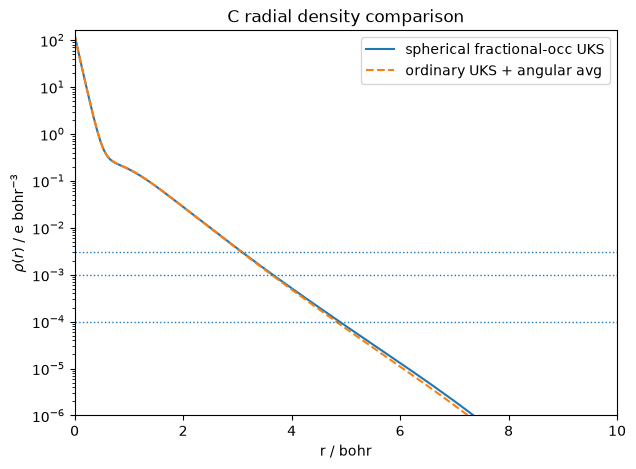

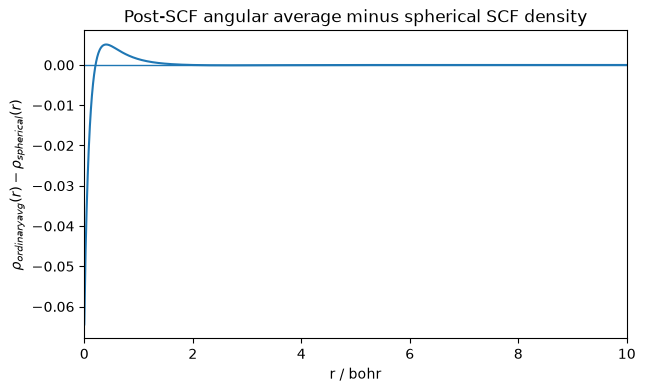

In [5]:
r = sph_profile["r_bohr"]
rho_sph = sph_profile["rho_e_bohr3"]
rho_plain = plain_profile["rho_e_bohr3"]

plt.figure(figsize=(7, 5))
plt.semilogy(r, rho_sph, label="spherical fractional-occ UKS")
plt.semilogy(r, rho_plain, "--", label="ordinary UKS + angular avg")
for cutoff in DENSITY_CUTOFFS:
    plt.axhline(cutoff, linestyle=":", linewidth=1)
plt.xlim(0.0, 10.0)
plt.ylim(1e-6, max(rho_sph.max(), rho_plain.max()) * 1.2)
plt.xlabel("r / bohr")
plt.ylabel(r"$\rho(r)$ / e bohr$^{-3}$")
plt.title(f"{state.symbol} radial density comparison")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(r, rho_plain - rho_sph)
plt.axhline(0.0, linewidth=1)
plt.xlim(0.0, 10.0)
plt.xlabel("r / bohr")
plt.ylabel(r"$\rho_{ordinary avg}(r) - \rho_{spherical}(r)$")
plt.title("Post-SCF angular average minus spherical SCF density")
plt.show()


## Interpretation

The spherical profile is the release density definition. The ordinary UKS profile is a diagnostic for the error introduced by solving a different atomic SCF problem and averaging only after convergence.

The most useful quantities to inspect are the density difference in the valence/tail region and shifts in the cutoff radii. Those are the features most likely to matter for empirical density and radius models.
